# Tuning Reinvent for drug discovery.

In this notebook, we show various plots and analysis with dummy data to indicate in a general way the effect of various Reinvent parameters.

# Effect of transforms on data in Reinvent.

Reinvent has various transforms available for your data (or you can define your own) to re-train its RL. Sometimes you want to penalise high values, other times you want to preserve a range and penalise values outside that range, depending on the quantity.  

Either way, Reinvent's RL works best if you use transforms, rather than raw data otherwise it can add too much bias to the model training. It is also worth remembering that the Reinvent RL assumes that higher transformed values mean a more desirable outcome for the RL. So, depending on your model, it might be necessary to transform to reflect this.

The below should only be used as a guide - **these parameters should be benchmarked, refined and carefully set** as they can lead to undesirable outcomes if set blindly.

Imports

In [54]:
import pandas as pd
import os
from IPython.display import display
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact
from itertools import product

from rdkit import Chem
from rdkit.Chem.rdRGroupDecomposition import RGroupDecompose
from rdkit.Chem import AllChem, Descriptors
from rdkit.Chem import Draw, Descriptors
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.rdDepictor import Compute2DCoords
from rdkit.Chem.TemplateAlign import AlignMolToTemplate2D

import useful_rdkit_utils as uru

## Reverve sigmoid transform for hERG

In this case, we have a ML model that predicts activity against the hERG ion channel. A common threshold for activity is `10 uM` and, in this case, the model is a binary classifier and outputs 0/1  (0=inactive, 1=active). The model itself and code for specification, training, etc. can be found in my Github 
[comp_chem/ml/adme_models/herg](https://github.com/coreytaylorcompchem/comp_chem/tree/main/ml/adme_models/herg).

The `reverse_sigmoid` transform has a reasonably good use case for binary hERG activity. It works when you have a quantity where a high value is bad and you want to penalise values that breach or approach it quite sharply, but values significantly less than the defined threshold are largely unpenalised in the model. As Reinvent interprets high = good and low = bad, the reverse transform is necessary to allow for the fact that a model prediction of 1 = active against hERG, which is the **undesirable outcome** that we want to penalise in re-training the RL.

Scoring function and tranform for the hERG model as defined in the `.toml`.

```
[[stage.scoring.component]]
[stage.scoring.component.herg]
[[stage.scoring.component.herg.endpoint]]
name = "herg inactive"
weight = 0.5
transform.type = "reverse_sigmoid"
transform.high = 1.0
transform.low = 0.0
transform.k = 10.0
params.model_file = "/home/corey/Documents/comp_chem/ml/adme_models/herg/herg_gnn.pt"
```


The above is largely self-explanatory for this use case; the transforms boundaries (`transform.high` and `transform.low`) reflect the goal of 0=inactive/good and 1=active/bad and the weight in the model depends on this goal (in this case, the file is for R-group enumeration).

The one parameter to really tune is the `transform.k`. How do we interpret and set this value? Here's some dummy data to illustrate the effect of the transform.

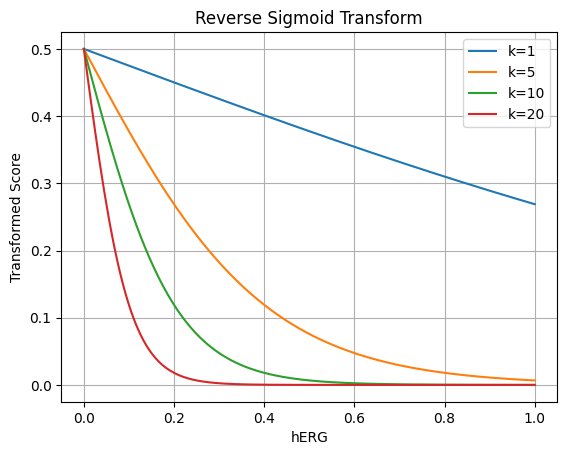

In [70]:
def reverse_sigmoid(x, high=1.0, low=0.0, k=10.0, x0=0.0):
    return low + (high - low) / (1 + np.exp(k * (x - x0)))

x_vals = np.linspace(0, 1, 200)
for k in [1, 5, 10, 20]:
    y_vals = reverse_sigmoid(x_vals, k=k, x0=0.0)
    plt.plot(x_vals, y_vals, label=f'k={k}')
    
plt.xlabel("hERG")
plt.ylabel("Transformed Score")
plt.title("Reverse Sigmoid Transform")
plt.legend()
plt.grid(True)
plt.show()


Clearly, at `k=10`, values from the model that approach the `transform.high` will be severely penalised. 

To illustrate, here are some examples from the Reinvent output using `transform.k` = 10.

In [67]:
data = {
  "SMILES": [
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(N4CCOCC4)cc3)c21', 
      'CC(NC(=O)c1cc(Cl)cc2ccn(C(=O)c3ccccc3)c12)c1ccc(C(F)(F)F)cc1', 
      'CC(=O)n1ccc2cc(Cl)cc(C(=O)NC(C)c3ccc(C4CC4)cc3)c21',
      'COc1cc(-c2ccc(C(C)NC(=O)c3cc(Cl)cc4ccn(C(C)=O)c34)cc2)ncc1C(F)(F)F', 
      ],
  "hERG_inactive": [1.0, 0.0, 0.9988612, 0.005883],
  "hERG_inactive_raw": [0.2839, 0.8453, 0.4706, 0.5223]
}

df = pd.DataFrame(data)

In [68]:
rdkit_img = Draw.MolsToGridImage(
    mols=[Chem.MolFromSmiles(s) for s in list(df.SMILES)],
    legends=[
        " ".join([" ", str(i)]) for i in zip(df['hERG_inactive'], df['hERG_inactive_raw'])
    ],
    molsPerRow=3,
    maxMols=50,
)

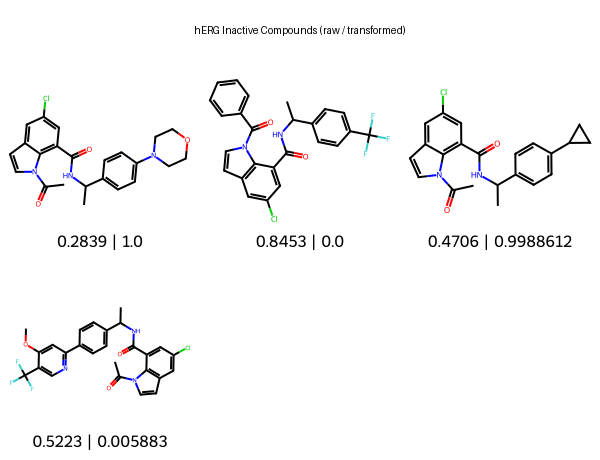

In [69]:
import io
from PIL import Image, ImageDraw, ImageFont
import math

mols_per_row = 3
sub_img_size = (200, 200)
title_height = 60
title_text = "hERG Inactive Compounds (raw / transformed)"

# Generate molecule images with legends
mols = [Chem.MolFromSmiles(s) for s in df.SMILES]
legends = [f"{i} | {j}" for i, j in zip(df["hERG_inactive_raw"], df["hERG_inactive"])]
mol_imgs = [Draw.MolToImage(m, size=sub_img_size, legend=legends[i]) for i, m in enumerate(mols)]

n_mols = len(mol_imgs)
n_rows = math.ceil(n_mols / mols_per_row)
grid_width = mols_per_row * sub_img_size[0]
grid_height = n_rows * sub_img_size[1]

grid_img = Image.new("RGB", (grid_width, grid_height), "white")

for idx, mol_img in enumerate(mol_imgs):
    row = idx // mols_per_row
    col = idx % mols_per_row
    x = col * sub_img_size[0]
    y = row * sub_img_size[1]
    grid_img.paste(mol_img, (x, y))

final_img = Image.new("RGB", (grid_img.width, grid_img.height + title_height), "white")

draw = ImageDraw.Draw(final_img)
try:
    font = ImageFont.truetype("arial.ttf", 32)
except:
    font = ImageFont.load_default()

bbox = draw.textbbox((0, 0), title_text, font=font)
text_width = bbox[2] - bbox[0]
text_height = bbox[3] - bbox[1]
text_x = (grid_img.width - text_width) // 2
text_y = (title_height - text_height) // 2
draw.text((text_x, text_y), title_text, fill="black", font=font)

final_img.paste(grid_img, (0, title_height))
display(final_img)

We can clearly see from the first two examples which molecules will be signalled as desirable to the RL from the raw and transformed values. For the first moleule, the model predicted a low probability of hERG activity (0.28) so the transformed value becomes 1, indicative of a desirable molecule to the Reinvent RL. The opposite is the case for the second molecule; a high probability (0.85) means a transform to 0, signalling an undesirable molecule to Reinvent.

The last two examples show edge cases where probabilities from the model that are close (0.48 vs 0.52) are treated quite sharply by the transform (0.99 vs 0.006). This signals to the RL desirable and undesireable molecules, respectively. That they aren't straight-up assigned 1.0 and 0.0, however, shows there is some subtlety in the transform and the value that will be passed to the RL. Tuning the `transform.k` will adjust this behaviour if you want a more gradual indicator. 